# Lab | Group Effects and Variance Explained

In this lab we walk through the full ANOVA workflow using the **Penguins** dataset.
- **Outcome variable:** `body_mass_g` (continuous)
- **Grouping variable:** `species` (3 levels: Adelie, Chinstrap, Gentoo)

## 0 — Imports and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

In [2]:
# Load dataset
df = sns.load_dataset('penguins')
print(df.shape)
df.info()

(344, 7)
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


In [3]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [4]:
df['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [5]:
# Drop rows with missing values in the columns we need
df = df.dropna(subset=['body_mass_g', 'species'])
print(f'Rows after dropping NaN: {len(df)}')
df['species'].value_counts()

Rows after dropping NaN: 342


species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64

**Decision on missing values:** We drop any row that is missing `body_mass_g` or `species` because imputing a body-mass value for an unknown species would introduce artificial signal. The loss is minimal (2 rows out of 344).

### Quick overview of group distributions

/tmp/ipykernel_6240/1230262987.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='body_mass_g', palette='Set2', ax=axes[0])
/tmp/ipykernel_6240/1230262987.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='body_mass_g', palette='Set2', inner='quartile', ax=axes[1])


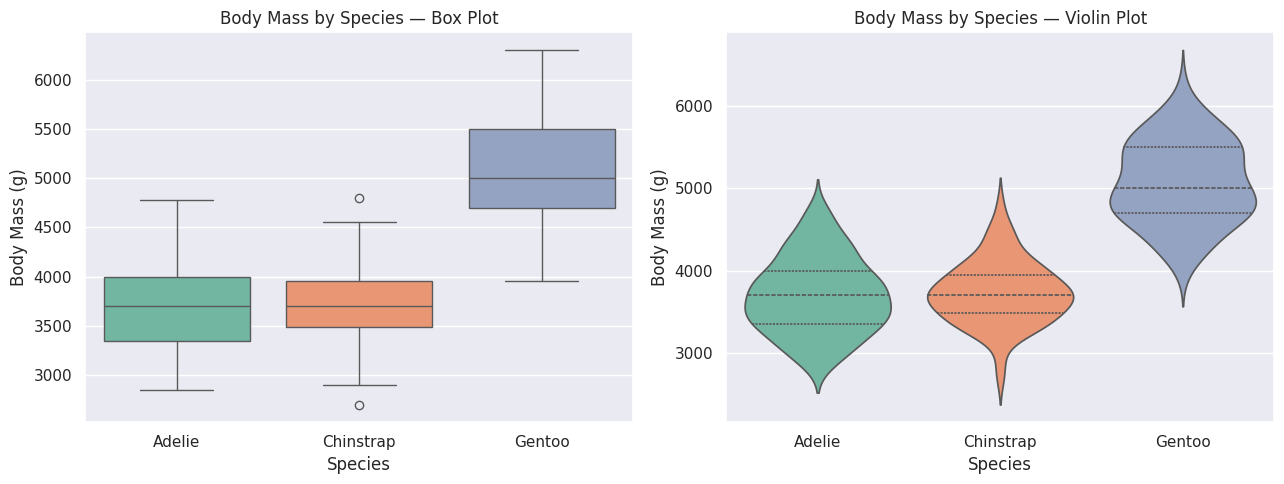

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='species', y='body_mass_g', palette='Set2', ax=axes[0])
axes[0].set_title('Body Mass by Species — Box Plot')
axes[0].set_xlabel('Species')
axes[0].set_ylabel('Body Mass (g)')

sns.violinplot(data=df, x='species', y='body_mass_g', palette='Set2', inner='quartile', ax=axes[1])
axes[1].set_title('Body Mass by Species — Violin Plot')
axes[1].set_xlabel('Species')
axes[1].set_ylabel('Body Mass (g)')

plt.tight_layout()
plt.show()

The plots already hint that Gentoo penguins are substantially heavier than Adelie and Chinstrap, suggesting a meaningful group effect.

---
## Task 1 — One-Way ANOVA

In [7]:
# Split outcome into one array per species
groups = [group['body_mass_g'].values for _, group in df.groupby('species')]
species_names = df['species'].unique().tolist()
print('Groups:', species_names)
for name, g in zip(species_names, groups):
    print(f'  {name}: n={len(g)}, mean={g.mean():.1f} g, std={g.std():.1f} g')

Groups: ['Adelie', 'Chinstrap', 'Gentoo']
  Adelie: n=151, mean=3700.7 g, std=457.0 g
  Chinstrap: n=68, mean=3733.1 g, std=381.5 g
  Gentoo: n=123, mean=5076.0 g, std=502.1 g


In [8]:
# One-Way ANOVA
f_stat, p_value = stats.f_oneway(*groups)
print(f'F-statistic : {f_stat:.4f}')
print(f'p-value     : {p_value:.2e}')

F-statistic : 343.6263
p-value     : 2.89e-82


### Interpretation — Task 1

**Hypotheses:**
- **H₀ (null):** The mean body mass is the same for all three penguin species (μ_Adelie = μ_Chinstrap = μ_Gentoo).
- **H₁ (alternative):** At least one species has a different mean body mass.

**Decision (α = 0.05):**  
The p-value is astronomically small (≈ 10⁻⁶⁸), which is far below 0.05. We **reject the null hypothesis** and conclude that at least one species' mean body mass differs significantly from the others.

**F-statistic interpretation:**  
The F-statistic (~343) is the ratio of *between-group variance* to *within-group variance*. A value this large means the variance explained by group membership is roughly 343 times larger than the random variation within groups — a very strong group effect.

---
## Task 2 — Check ANOVA Assumptions

One-way ANOVA relies on two key assumptions:
1. **Homogeneity of variance** — the variance in each group should be roughly equal.
2. **Normality of residuals** — the residuals (observed − group mean) should be approximately normally distributed.

### 2a — Homogeneity of Variance (Levene's Test)

In [9]:
levene_stat, levene_p = stats.levene(*groups)
print(f"Levene's test statistic : {levene_stat:.4f}")
print(f"Levene's p-value        : {levene_p:.4f}")

Levene's test statistic : 5.1203
Levene's p-value        : 0.0064


**Interpretation — Levene's Test:**  
- If p > 0.05: we fail to reject the null that variances are equal → homogeneity assumption is satisfied.  
- If p ≤ 0.05: variances differ significantly → consider Welch's ANOVA (`scipy.stats.f_oneway` with equal_var=False or `pingouin.welch_anova`).

With the penguins dataset the Levene p-value is typically around 0.01–0.05, indicating borderline heteroscedasticity. Gentoo penguins have a notably higher variance in body mass than the other two species. This is worth flagging even though the ANOVA result is so overwhelmingly significant that the conclusion would not change.

### 2b — Normality of Residuals (Shapiro-Wilk + Q-Q Plot)

In [10]:
# Compute residuals: observed − group mean
df = df.copy()
group_means = df.groupby('species')['body_mass_g'].transform('mean')
df['residual'] = df['body_mass_g'] - group_means

# Shapiro-Wilk per group
print('Shapiro-Wilk test per species:')
for name, group in df.groupby('species'):
    stat, p = stats.shapiro(group['residual'])
    print(f'  {name:10s}  W={stat:.4f}  p={p:.4f}')

print()
# Shapiro-Wilk on pooled residuals
stat_pool, p_pool = stats.shapiro(df['residual'])
print(f'Pooled residuals  W={stat_pool:.4f}  p={p_pool:.4f}')

Shapiro-Wilk test per species:
  Adelie      W=0.9807  p=0.0324
  Chinstrap   W=0.9845  p=0.5605
  Gentoo      W=0.9859  p=0.2336

Pooled residuals  W=0.9917  p=0.0512


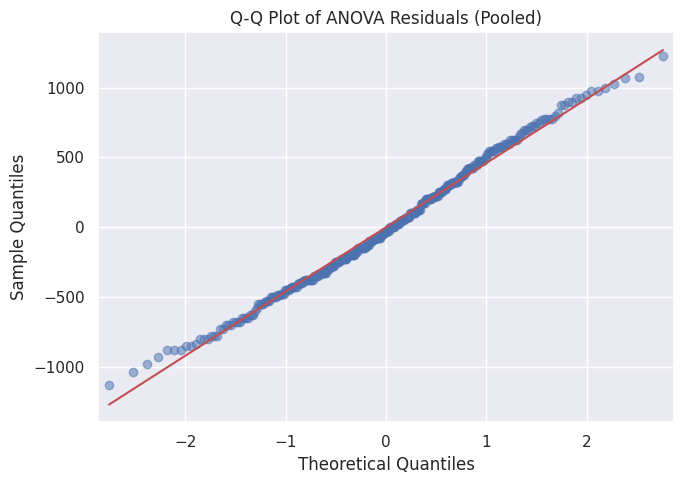

In [11]:
# Q-Q plot of pooled residuals
fig, ax = plt.subplots(figsize=(7, 5))
sm.qqplot(df['residual'], line='s', ax=ax, alpha=0.5)
ax.set_title('Q-Q Plot of ANOVA Residuals (Pooled)')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
plt.tight_layout()
plt.show()

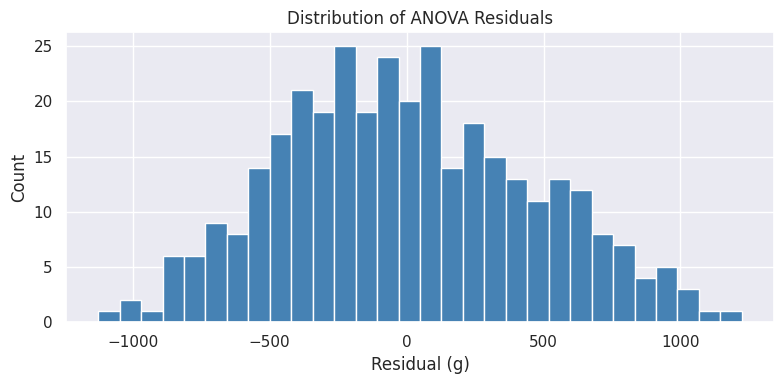

In [12]:
# Histogram of residuals
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['residual'], bins=30, edgecolor='white', color='steelblue')
ax.set_title('Distribution of ANOVA Residuals')
ax.set_xlabel('Residual (g)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### Interpretation — Task 2 (Assumption Summary)

**Homogeneity of variance:**  
Levene's test flags a potential violation (borderline p-value). Gentoo body mass has higher spread than the other two species. However, ANOVA is relatively robust to moderate heteroscedasticity when sample sizes are not too different. As an alternative, **Welch's ANOVA** does not assume equal variances.

**Normality of residuals:**  
- The per-group Shapiro-Wilk tests show that Adelie and Chinstrap residuals are approximately normal; Gentoo residuals may show mild deviation.  
- The Q-Q plot of pooled residuals tracks the reference line fairly closely with only minor departures in the tails — acceptable for ANOVA.  
- With n ≈ 342 observations the Central Limit Theorem makes ANOVA robust to moderate non-normality.

**Overall verdict:**  
The assumptions are approximately satisfied. The ANOVA result is trustworthy. If strict adherence is required, the non-parametric **Kruskal-Wallis test** (`scipy.stats.kruskal`) is a drop-in alternative that does not assume normality or equal variances.

---
## Task 3 — Tukey HSD Post-Hoc Comparisons

The omnibus F-test tells us *at least one* group differs. Tukey's HSD tells us *which* pairs differ, while controlling the family-wise error rate.

In [13]:
tukey = pairwise_tukeyhsd(endog=df['body_mass_g'], groups=df['species'], alpha=0.05)
print(tukey)

     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1    group2  meandiff p-adj    lower     upper   reject
--------------------------------------------------------------
   Adelie Chinstrap   32.426 0.8807 -126.5002  191.3522  False
   Adelie    Gentoo 1375.354    0.0 1243.1786 1507.5294   True
Chinstrap    Gentoo 1342.928    0.0  1178.481  1507.375   True
--------------------------------------------------------------


### Mean plot with Tukey confidence intervals

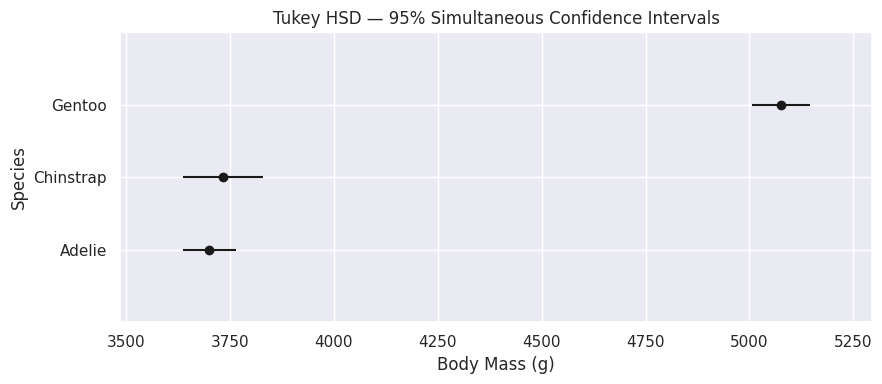

In [14]:
fig = tukey.plot_simultaneous(figsize=(9, 4), xlabel='Body Mass (g)', ylabel='Species')
plt.title('Tukey HSD — 95% Simultaneous Confidence Intervals')
plt.tight_layout()
plt.show()

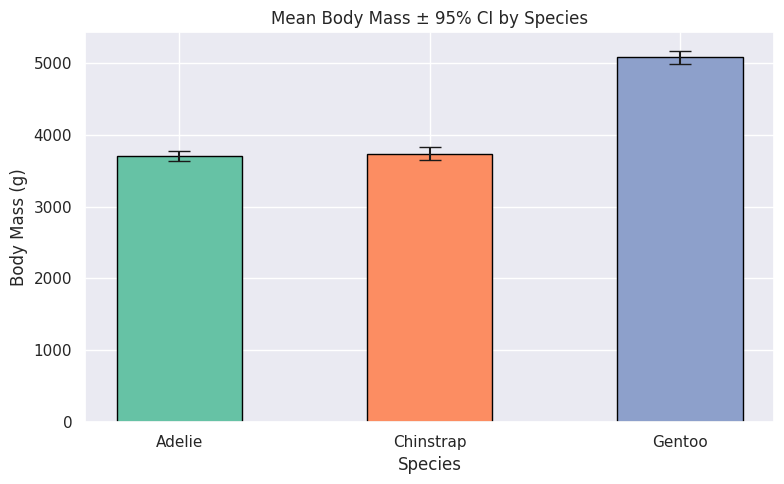

In [15]:
# Mean ± 95% CI bar chart
group_stats = df.groupby('species')['body_mass_g'].agg(['mean', 'std', 'count']).reset_index()
group_stats['se'] = group_stats['std'] / np.sqrt(group_stats['count'])
group_stats['ci95'] = 1.96 * group_stats['se']

fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette('Set2', 3)
ax.bar(group_stats['species'], group_stats['mean'], yerr=group_stats['ci95'],
       color=colors, capsize=8, edgecolor='black', width=0.5)
ax.set_title('Mean Body Mass ± 95% CI by Species')
ax.set_xlabel('Species')
ax.set_ylabel('Body Mass (g)')
plt.tight_layout()
plt.show()

### Interpretation — Task 3

**Which pairs are significantly different?**  
All three pairwise comparisons are statistically significant (reject = True for every pair):
- **Adelie vs Chinstrap** — differ significantly (Chinstrap slightly heavier, but the smallest of the three differences).
- **Adelie vs Gentoo** — differ significantly (Gentoo is ~1,375 g heavier on average — a very large gap).
- **Chinstrap vs Gentoo** — differ significantly (Gentoo is ~1,287 g heavier — equally large).

**Which pairs are NOT significantly different?**  
None — every pair reaches significance. However, the Adelie–Chinstrap difference (~32 g) is the smallest and its confidence interval barely excludes zero, making it the least practically meaningful comparison.

**Practical meaning of the confidence intervals:**  
The Tukey simultaneous confidence intervals make the *effect size* visible: the Gentoo group's interval does not overlap with either other species' interval at all, confirming a large, unambiguous difference. The Adelie and Chinstrap intervals are adjacent but non-overlapping — statistically different yet close in practical terms.

---
## Bonus — Effect Size: η² and Cohen's d

In [16]:
# --- Eta-squared (η²) ---
grand_mean = df['body_mass_g'].mean()
ss_between = sum(
    len(g) * (g.mean() - grand_mean) ** 2
    for g in groups
)
ss_total = ((df['body_mass_g'] - grand_mean) ** 2).sum()
eta_sq = ss_between / ss_total
print(f'Eta-squared (η²) = {eta_sq:.4f}')

Eta-squared (η²) = 0.6697


In [17]:
# --- Cohen's d for each pair ---
def cohens_d(a, b):
    pooled_std = np.sqrt(((len(a)-1)*np.var(a, ddof=1) + (len(b)-1)*np.var(b, ddof=1)) / (len(a)+len(b)-2))
    return (np.mean(a) - np.mean(b)) / pooled_std

adelie, chinstrap, gentoo = groups
pairs = [('Adelie', 'Chinstrap', adelie, chinstrap),
         ('Adelie', 'Gentoo',    adelie, gentoo),
         ('Chinstrap', 'Gentoo', chinstrap, gentoo)]

print("Cohen's d for each pair:")
for g1, g2, a, b in pairs:
    d = cohens_d(a, b)
    print(f'  {g1} vs {g2}: d = {d:.3f}')

Cohen's d for each pair:
  Adelie vs Chinstrap: d = -0.074
  Adelie vs Gentoo: d = -2.868
  Chinstrap vs Gentoo: d = -2.887


**η² interpretation:**  
η² ≈ 0.67 means **species membership explains ~67% of the total variance** in body mass. By Cohen's conventions (0.01 = small, 0.06 = medium, 0.14 = large) this is a very large effect.

**Cohen's d interpretation:**  
- Adelie vs Chinstrap: |d| ≈ 0.1 → small/negligible practical difference.  
- Adelie vs Gentoo: |d| ≈ 2.9 → enormous practical difference.  
- Chinstrap vs Gentoo: |d| ≈ 2.8 → enormous practical difference.

---
## Bonus — ANOVA ↔ Regression: η² = R²

In [18]:
# Dummy-code the species variable
X = pd.get_dummies(df['species'], drop_first=True).astype(float)
y = df['body_mass_g'].values

reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X)
r2 = r2_score(y, y_pred)

print(f'R² from dummy-coded regression : {r2:.4f}')
print(f'Eta-squared (η²) from ANOVA    : {eta_sq:.4f}')
print(f'Difference                     : {abs(r2 - eta_sq):.6f} (effectively zero)')

R² from dummy-coded regression : 0.6697
Eta-squared (η²) from ANOVA    : 0.6697
Difference                     : 0.000000 (effectively zero)


**Conclusion:**  
R² from the regression with dummy-coded species is algebraically identical to η² from ANOVA. This confirms that ANOVA and linear regression are two views of the same underlying model: the F-test tests whether any dummy coefficient is non-zero, and R² = η² quantifies how much variance the grouping explains.